# Customer Retention Analysis — Olist Marketplace

**Question:** What percentage of Olist customers are repeat buyers, and is the retention rate trending up or down?

**Stakeholder:** Head of Marketing

**Output:** Headline retention rate + bar chart (one-time vs repeat) + trend chart over time

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')

In [2]:
customers.shape
customers.info()
customers.head()
customers.isnull().sum()
customers['customer_unique_id'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


96096

In [3]:
orders.shape
orders.info()
orders.head()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [4]:
merged = pd.merge(orders, customers,on='customer_id')
merged = merged[merged['order_status'] == 'delivered']
order_counts = merged.groupby('customer_unique_id').size()
customer_summary = order_counts.reset_index(name = 'order_count')
customer_summary.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [5]:
import numpy as np
customer_summary['customer_type'] =  np.where(customer_summary['order_count'] >= 2,'Repeat','One-time')
customer_summary.head()
customer_summary['customer_type'].value_counts()

customer_type
One-time    90557
Repeat       2801
Name: count, dtype: int64

In [6]:

repeat_rate = customer_summary[customer_summary['customer_type'] == 'Repeat'].shape[0] / customer_summary.shape[0] * 100
print(f"Repeat customer rate: {repeat_rate:.2f}%")

Repeat customer rate: 3.00%


In [7]:
summary = customer_summary['customer_type'].value_counts()
print(summary)

customer_type
One-time    90557
Repeat       2801
Name: count, dtype: int64


In [8]:
print(summary.index)
print(summary.values)

Index(['One-time', 'Repeat'], dtype='object', name='customer_type')
[90557  2801]


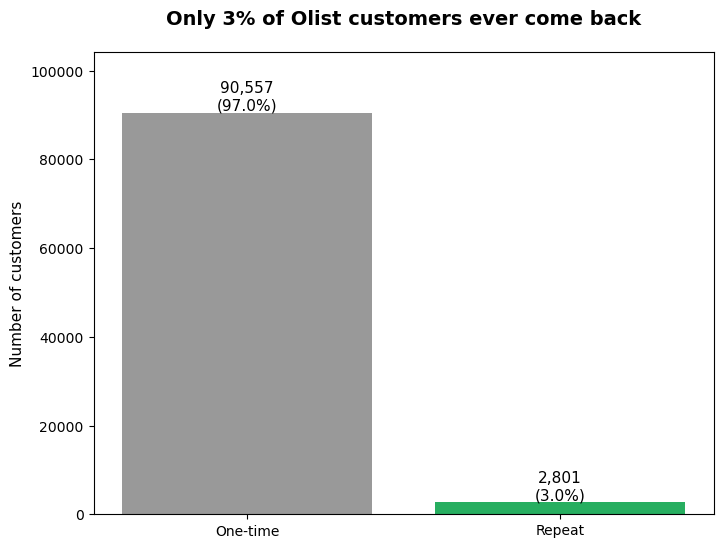

In [9]:
plt.figure(figsize=(8,6))
bars = plt.bar(summary.index,summary.values,color=['#999999', '#27ae60'])
plt.title('Only 3% of Olist customers ever come back', fontsize = 14,fontweight = 'bold',pad=20)
plt.ylabel('Number of customers',fontsize = 11)

total = summary.values.sum()
for bar, count in zip(bars, summary.values):
    pct = count/total * 100
    label = f'{count:,}\n({pct:.1f}%)'
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             label,
             ha='center', fontsize=11)
plt.ylim(0, summary.values.max() * 1.15)
plt.savefig('../images/01_customer_retention.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
import os
os.listdir('../images')

['01_customer_retention.png']

In [13]:
merged['order_purchase_timestamp'] = pd.to_datetime(merged['order_purchase_timestamp'])
merged['year']=merged['order_purchase_timestamp'].dt.year
merged['year'].value_counts().sort_index()
                                        

year
2016      267
2017    43428
2018    52783
Name: count, dtype: int64

In [14]:
merged['year_month']= merged['order_purchase_timestamp'].dt.to_period('M')
merged['year_month'].head()

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: year_month, dtype: period[M]

In [15]:
monthly_orders = merged.groupby('year_month').size().sort_index()
monthly_orders

year_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, dtype: int64

In [16]:
monthly_orders_trimmed = monthly_orders[monthly_orders.index >= '2017-01']
monthly_orders_trimmed

year_month
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, dtype: int64

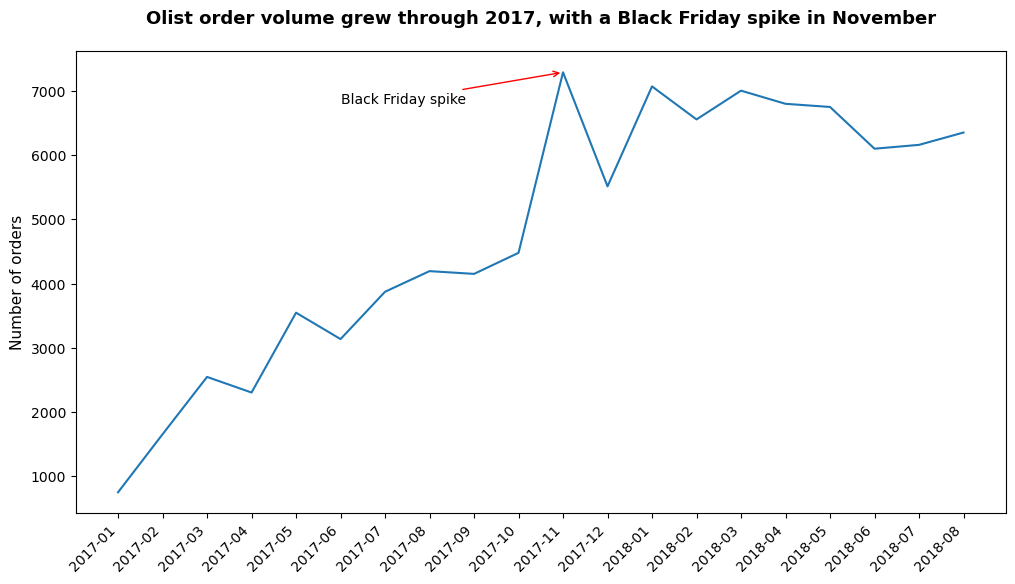

In [22]:
plt.figure(figsize=(12,6))
plt.plot(monthly_orders_trimmed.index.astype(str),monthly_orders_trimmed.values)
plt.title('Olist order volume grew through 2017, with a Black Friday spike in November', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Number of orders', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.annotate('Black Friday spike',
             xy=('2017-11', 7289),
             xytext=('2017-06', 6800),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10)
plt.savefig('../images/02_monthly_order_volume.png', dpi=150, bbox_inches='tight')
plt.show()

**Key finding: Olist has a severe customer retention problem.**

Only 3% of customers ever make a second purchase, just 2,801 repeat buyers out of 93,358. For context, healthy e-commerce repeat rates typically run 20 to 30%, so Olist is losing nearly every customer after their first order.

Order volume tells a growth story. Monthly orders climbed steadily through 2017, with a clear spike in November 2017 that is almost certainly Black Friday. This shows Olist is effective at acquiring customers, even as it struggles to keep them.

**Data caveat:** The dataset spans late 2016 to August 2018. The 2016 months contain only a handful of orders, so I excluded them to avoid distorting the trend. The 2018 data is also partial, ending in August, so the apparent leveling off in 2018 is an artifact of the data cutoff rather than a real slowdown.

**Recommendation:** Because acquisition is working but retention is not, the biggest opportunity is converting one-time buyers into repeat customers. A targeted post-purchase win-back campaign, such as a follow-up offer after a customer's first delivered order, could lift the repeat rate even a few points, which at Olist's volume would translate into substantial revenue.